In [ ]:
from pathlib import Path

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import xarray as xr
from context_flux_no.models.dpot import DPOT
from context_flux_no.training import PDEDataset
from context_flux_no.training.loader import ContextSegmentLoader
from jaxtyping import Array, Float

# jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_captured_constants_report_frames", -1)


In [20]:
dpot = DPOT(
    num_spatial_dims=1,
    in_channels=1,
    out_channels=1,
    in_timesteps=20,
    patch_size=(4,),
    img_size=(100,),
    embedding_dim=96,
    max_frequency_modes=(10,),
    fno_depth=5,
    num_blocks=4,
    num_classes=12,
    hidden_dim_patch=96,
    hidden_dim_fno=96,
    key=jax.random.key(0),
)

In [17]:
img_1d = jnp.ones((20, 1, 100))
dpot(img_1d)[0].shape

(1, 100)

In [10]:
# jax.config.update("jax_enable_x64", True)

datadir = Path("./data")
dataset_xr = xr.load_dataset(datadir / "cubic_no_source_large_train.hdf5")
# dataset_xr = xr.open_mfdataset(
#     sorted(list(datadir.glob("cubic_no_source_large_train_seed=*.hdf5"))),
#     combine="nested",
#     concat_dim="pde",
#     engine="h5netcdf",
# )
dataset_xr

<xarray.Dataset> Size: 40GB
Dimensions:  (pde: 1000, ic: 100, t: 1001, dim: 1, x: 100, param: 3)
Coordinates:
  * t        (t) float64 8kB 0.0 0.0005 0.001 0.0015 ... 0.4985 0.499 0.4995 0.5
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * dim      (dim) <U1 4B 'u'
  * param    (param) <U1 12B 'a' 'b' 'c'
Dimensions without coordinates: pde, ic
Data variables:
    values   (pde, ic, t, dim, x) float32 40GB 0.3343 0.219 ... -0.4966 -0.5188
    coeffs   (pde, param) float32 12kB -0.8828 -0.9787 ... -0.5751 -0.03708

/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/training/dataset.py:33: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return cls(u, t, x, coeffs, dim_names, coeff_names)
/home/jhko725/.local/share/uv/python/cpython-3.12.9-linux-x86_64-gnu/lib/python3.12/dataclasses.py:1588: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return obj.__class__(**changes)


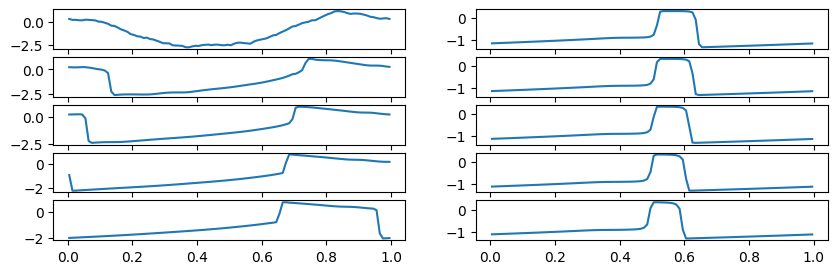

In [11]:
# Do the downsampling before on the dask arrays to make things speedier
dataset_train, dataset_test = (
    PDEDataset.from_xarray(dataset_xr).downsample_time(10).split_by_time(80)
)

fig, axes = plt.subplots(5, 2, figsize=(10, 3))
for i in range(axes.shape[0]):
    axes[i, 0].plot(dataset_train.x, dataset_train.u[0, 0, i * 4, 0])
    axes[i, 1].plot(dataset_test.x, dataset_test.u[0, 0, i * 4, 0])

In [12]:
loader = ContextSegmentLoader(
    dataset_train, context_size=20, segment_length=2, batch_size=1024
)
batch, _ = loader.load_batch(loader.init())

In [18]:
batch[1].shape

(1024, 2, 1, 100)

In [23]:
def loss_fn(
    model, batch: tuple[Float[Array, "..."], ...]
) -> tuple[Float[Array, ""], dict]:
    context, u, dt, dx = batch
    u0, u1 = u[:, 0], u[:, 1]
    u1_pred = eqx.filter_vmap(model)(context)[0]
    return jnp.mean((u1 - u1_pred) ** 2), dict()


In [24]:
loss_fn(dpot, batch)

(Array(1.362935, dtype=float32), {})

In [ ]:
from context_flux_no.utils import num_parameters


num_parameters(dpot)

336209

In [ ]:
def train(
    model,
    dataloader: ContextSegmentLoader,
    optimizer: optax.GradientTransformation,
    loss_fn,
    max_steps: int,
):
    loss_grad_fn = eqx.filter_value_and_grad(loss_fn, has_aux=True)

    @eqx.filter_jit
    def train_step(model_, loader_state_, opt_state_):
        batch, loader_state_next = dataloader.load_batch(loader_state_)
        (loss, aux), grads = loss_grad_fn(model_, batch)
        updates, opt_state_next = optimizer.update(
            grads, opt_state_, eqx.filter(model_, eqx.is_array)
        )
        model_ = eqx.apply_updates(model_, updates)
        return loss, aux, model_, loader_state_next, opt_state_next

    loader_state = dataloader.init()
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

    loss_history = []
    try:
        for i in range(max_steps):
            loss, aux, model, loader_state, opt_state = train_step(
                model, loader_state, opt_state
            )

            loss_scalar = loss.item()
            print(f"Step: {i}: loss = {loss_scalar}")
            loss_history.append(loss_scalar)
    finally:
        return model, jnp.asarray(loss_history)